In [210]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

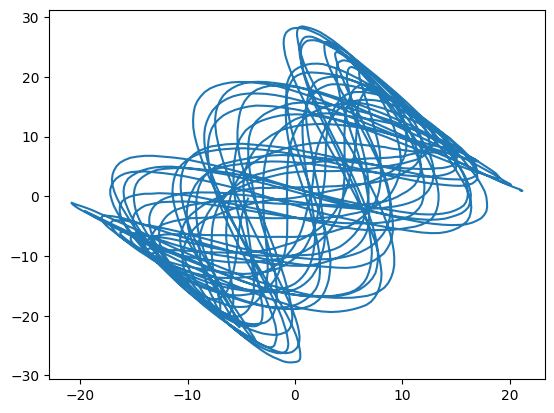

In [211]:
filename = '29_using_gravity_1_angles.csv'
t, x1, y1, x2, y2, th1, th2, om1, om2, _, L1, L2 = np.genfromtxt(filename, usecols=range(12), \
                                           delimiter=',', skip_header=100).T
phi1 = th1 - np.mean(th1)
phi2 = th2 - np.mean(th2)
plt.plot(phi1, phi2)

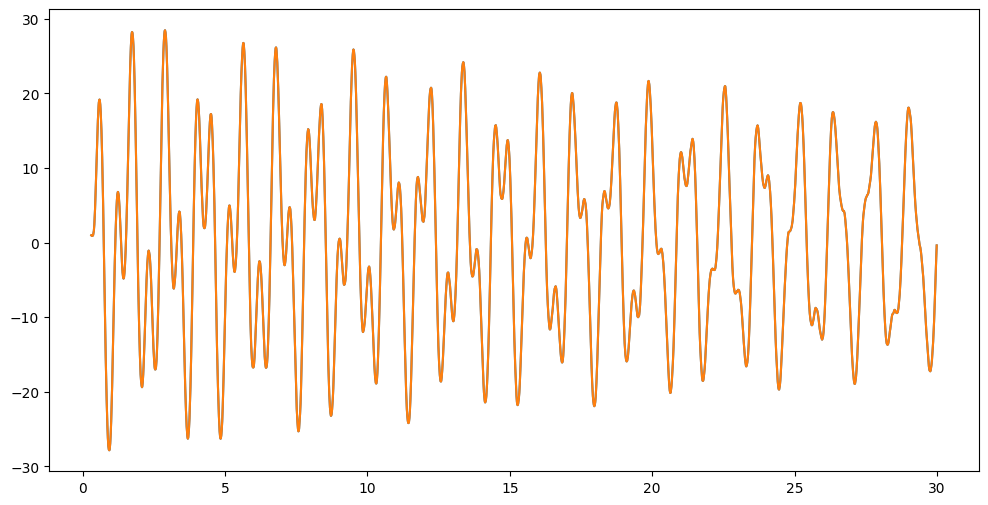

In [212]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
mask = (t > 0)  & ~np.isnan(phi2)
ax.plot(t[mask], phi2[mask])
plt.plot(t[mask], phi2[mask])

# Observed eigen frequencies

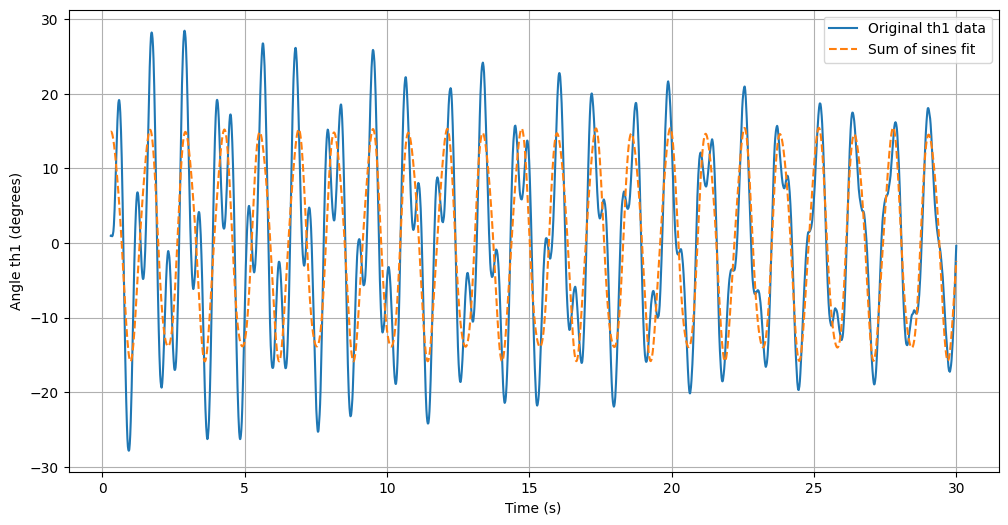

Fitted parameters:
A1: -14.848, omega1: 4.814 rad/s, f1: 0.766 Hz
A2: 1.029, omega2: 12.049 rad/s, f2: 1.918 Hz


In [213]:
from scipy.optimize import curve_fit


# Define the sum of sines function (e.g., two sines with an offset)
def sum_of_sines(t, A1, omega1, psi1, A2, omega2, psi2):
    return A1 * np.sin(omega1 * t + psi1) + A2 * np.sin(omega2 * t + psi2)

# Initial guess for the parameters: [A1, omega1, psi1, A2, omega2, psi2]
# Based on visual inspection of the 'th1' plot:
# - Amplitudes (A1, A2) are roughly half of the total amplitude (approx 20-25), so 10-15 each.
# - Frequencies (omega1, omega2) derived from periods of ~1-2 seconds (omega = 2*pi/period), so ~3 to 6 rad/s.
# - Phases (psi1, psi2) can start at 0.
# - Offset (C) appears to be close to 0.
initial_guess = [30, 5, 0, 30, 12, 0]

try:
    # Perform the curve fit
    params, covariance = curve_fit(sum_of_sines, t[mask], phi2[mask], p0=initial_guess, maxfev=5000)

    # Generate the fitted curve using the optimized parameters
    phi2_fit = sum_of_sines(t[mask], *params)

    # Plot the original data and the fitted curve
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    ax.plot(t[mask], phi2[mask], label='Original th1 data')
    ax.plot(t[mask], phi2_fit, label='Sum of sines fit', linestyle='--')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Angle th1 (degrees)')
    ax.legend()
    plt.grid(True)
    plt.show()

    print("Fitted parameters:")
    print(f"A1: {params[0]:.3f}, omega1: {params[1]:.3f} rad/s, f1: {params[1]/2/np.pi:.3f} Hz")
    print(f"A2: {params[3]:.3f}, omega2: {params[4]:.3f} rad/s, f2: {params[4]/2/np.pi:.3f} Hz")

except RuntimeError as e:
    print(f"Error during curve fitting: {e}")
    print("Curve fitting failed. This could be due to poor initial guesses or the model not adequately representing the data.")
    print("Consider adjusting the initial_guess values, increasing maxfev, or trying a different model.")

# Expected eigen frequencies

In [214]:
phi1 = th1 / 180 * np.pi
phi2 = (th2 - th1) / 180 * np.pi
o1 = om1 / 180 * np.pi
o2 = (om2 - om1) / 180 * np.pi
m1 = 0.436
m2 = 0.497
l1 = 0.215
l2 = 0.215
g = 9.8
l3 = 0.255
T1 = 1.0
T2 = 1.0
# moment intertia at rotation point
I1 = m1 * g * l1 * (T1 / 2 / np.pi)**2
I2 = m2 * g * l2 * (T2 / 2 / np.pi)**2
# moment intertia at center of the mass
I1_cm = I1 - m1 * l1**2
I2_cm = I2 - m2 * l2**2
print(I1_cm, I2_cm)
print(I1, I2)
c1 = m2**2 * g * l2**2 * l3 - I2 *g * (m1*l1 + m2* l3)
c2 = m2**2 * g * l2**2 * l3
c3 = I2*g * (m1*l1 + m2* l3)  + m2*g*l2 * (m1*l1*l3 - I1 - m2*l2*l3)
c4 = - m2*g*l2 * (m2*l2*l3 + m2*l3**2 + I1)
d = I2 * (I1 +m2*l3**2) - (m2* l2*l3)**2
om1_expected = np.sqrt((-(c1+c4) + np.sqrt((c1+c4)**2 - 4 * (c1*c4 - c2*c3)) ) / 2 / d)
om2_expected = np.sqrt((-(c1+c4) - np.sqrt((c1+c4)**2 - 4 * (c1*c4 - c2*c3)) ) / 2 / d)
print("Calculated parameters:")
print(f"omega1: {om1_expected:.3f} rad/s, f1: {om1_expected/2/np.pi:.3f} Hz")
print(f"omega2: {om2_expected:.3f} rad/s, f2: {om2_expected/2/np.pi:.3f} Hz")

0.003115626998850228 0.0035515289413499164
0.023269726998850226 0.026525353941349913
Calculated parameters:
omega1: 11.615 rad/s, f1: 1.849 Hz
omega2: 4.787 rad/s, f2: 0.762 Hz


# Kinetic energy

Kinetic energy is sum of
- first pendulum rotational energy $\frac{1}{2} I_1 \dot\theta_1^2$
- second pendulum rotational energy relative to c.o.m. $\frac{1}{2} I_2^{cm} \dot\theta_2^2$
- ans second pendulum c.o.m. translational energy $\frac{1}{2} m_2v_2^2$

$$
K = \frac{1}{2} I_1 \dot\phi_1^2 + \frac{1}{2} I_2^{\textrm{cm}} (\dot\phi_1 + \dot\phi_2)^2 + \frac{1}{2}m_2 v_2^2  
$$

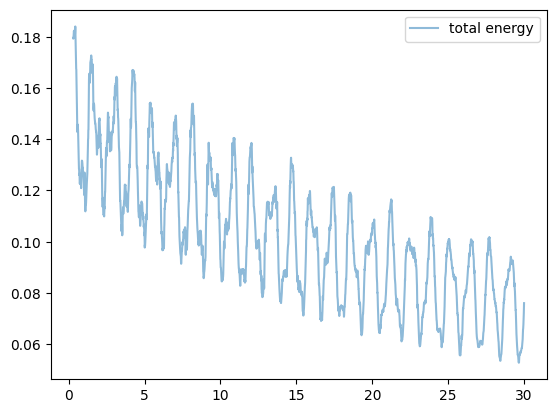

In [215]:


# rod 2 center of the mass coordinates
x2_cm = l3 * np.sin(phi1) + l2 * np.sin(phi1 + phi2)
y2_cm =  l3 * np.cos(phi1) + l2 * np.cos(phi1 + phi2)
x2_cm_dot, y2_cm_dot = np.gradient(x2_cm, t), np.gradient(y2_cm, t)
x2_cm_dot, y2_cm_dot = savgol_filter(x2_cm_dot, 51, 3), savgol_filter(y2_cm_dot, 51, 3)
#o1, o2 = savgol_filter(o1, 51, 3), savgol_filter(o2, 51, 3)
# rod 2 c.o.m. velocity squared
v2_cm_squared = x2_cm_dot**2 + y2_cm_dot**2

K1 = I1 * o1**2 / 2
K2 = I2_cm * (o1 + o2)**2 / 2
K3 = m2 *v2_cm_squared / 2
K = K1 + K2 + K3



U = g * ( m1 *l1 + m2*l3) *  ( 1 - np.cos(phi1))  + g* m2 *  l2 * (1 - np.cos(phi1 + phi2))

E = K + U
plt.plot(t, E, '-', alpha=0.5, label='total energy')

plt.legend()



# Total energy

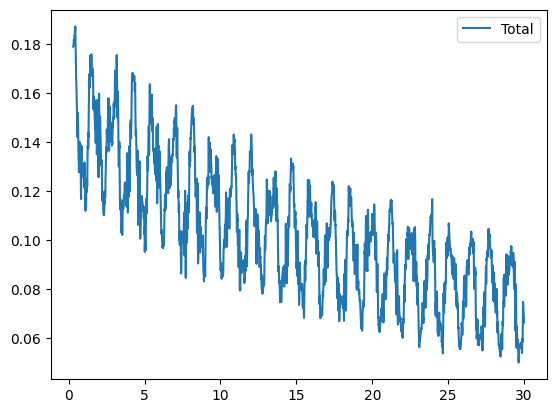

In [216]:
# Kinetic energy
T = 1/2* (I1 + m2*l3**2) * o1 **2 +\
    1/2* I2 *(o1 + o2)**2 +\
    m2 * l2* l3 * o1 * (o1 + o2) * np.cos(phi2)

# potential energy
U = g * (m1 * l1 + m2* l3) * (1 - np.cos(phi1)) +\
    g * m2 * l2 * (1 - np.cos(phi1 + phi2))

plt.plot(t, T+U, label='Total')
#plt.plot(t, K, label='K', alpha=0.1, color='gray')
plt.legend()
#plt.xlim(5, 12)

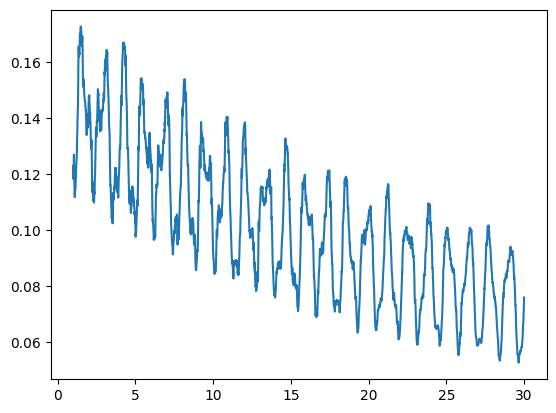

In [217]:
mask = t > 1
plt.plot(t[mask], E[mask])

In [218]:
def total_energy(th1, th2, w1, w2, L1, L2, m1, m2, g=9.81,
                 c1=None, c2=None, I1=0.0, I2=0.0):
    """Total energy of the double pendulum, in joules.

    Compound bodies: beam k has mass m_k, its centre of mass sits c_k from its
    upper axle and its moment of inertia about that centre of mass is I_k. With
    c_k = L_k and I_k = 0 this collapses to point masses at the joints.

        T = 1/2 (I1 + m1 c1^2) w1^2
          + 1/2 m2 (L1^2 w1^2 + c2^2 w2^2 + 2 L1 c2 w1 w2 cos(th1 - th2))
          + 1/2 I2 w2^2
        V = -(m1 c1 + m2 L1) g cos(th1) - m2 g c2 cos(th2)

    Zero is both rods hanging straight down at rest: E = T + V - V(rest).
    """
    c1 = L1 if c1 is None else c1
    c2 = L2 if c2 is None else c2
    T = (0.5 * (I1 + m1 * c1 ** 2) * w1 ** 2
         + 0.5 * m2 * (L1 ** 2 * w1 ** 2 + c2 ** 2 * w2 ** 2
                       + 2 * L1 * c2 * w1 * w2 * np.cos(th1 - th2))
         + 0.5 * I2 * w2 ** 2)
    V = -(m1 * c1 + m2 * L1) * g * np.cos(th1) - m2 * g * c2 * np.cos(th2)
    V0 = -(m1 * c1 + m2 * L1) * g - m2 * g * c2
    return T + V - V0
E = total_energy(phi1, phi1+phi2, om1, om2, l3, l3, m1, m2, 9.8, l1, l2, I1, I2)

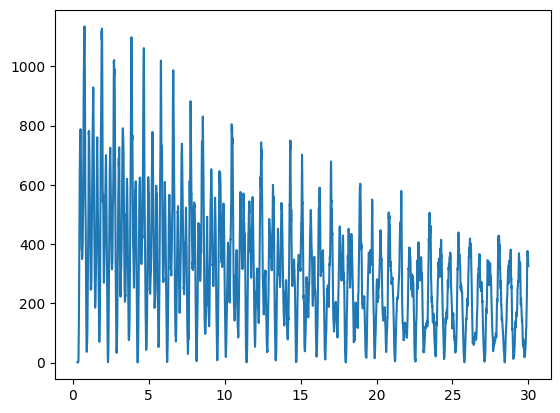

In [219]:
plt.plot(t, E)